# **Case Study: How Can a Wellness Technology Company Play It Smart?**


**Author**: DataAngel10
-------
**Date**: 20-07-2025
-------

# **1. Company summary**


Bellabeat is a high-tech company founded in 2013 by Urška Sršen and Sando Mur. The company develops health-focused products for women, combining elegant design with smart health features that collect data on activity (steps taken, distanced traveled, calories burned and activity minutes), sleep, stress, heart rate, respiratory rate, and reproductive health. The goal is to help users gain insights into their overall health and habits.
By 2016, Bellabeat expanded globally and sold products via online retailers and its own website (www.Bellabeat.com). The company focuses mostly on digital marketing using platform such as Google, social media, YouTube, and display ads.


### Bellabeat products:

1) **Ivy / Ivy+** :A wellness bracelet that monitors heart rate, respiratory rate, sleep stages, stress, and menstrual cycles, with personalized wellness scores.
   
2) **Leaf**: A wearable wellness tracker that can be worn as a necklace, bracelet, or clip.
It tracks activity, sleep, and stress.


3) **Time**: A smartwatch with wellness tracking features such as activity, sleep, and stress.

   
4) **Spring**: A smart water bottle that tracks user hydration.

 
5) **Bellabeat App**: Application that users can pair with Bellabeat's products and allow users to track their health metrics.


6) **Bellabeat+ Club Membership**: It has 24/7 access to personalized wellness guidance.


Sršen has asked the marketing analytics team **to analyze how users interact with smart devices to uncover meaningful patterns**. These insights will guide strategic recommendations to support Bellabeat’s marketing and future growth.


# **2. Ask**


## 2.1. Business Task:

To analyze smart fitness device data to understand how users interact with health tracking features, and to generate data-driven recommendations that improve Bellabeat’s marketing strategy, support product growth, and attract more customers.


## 2.2. Business Questions:

1. What are some trends in smart device usage?
2. How could these trends apply to Bellabeat customers?
3. How could these trends help influence Bellabeat marketing strategy?



## 2.3. Key stakeholders:
   - Urška Sršen (Cofounder & Chief Creative Officer)  
   - Sando Mur (Cofounder)  
   - Bellabeat Marketing Analytics Team  


# **3. Prepare**

## 3.1. Data Source
For this project, `Fitbit Fitness Tracker' data was used. This is a folders with several datasets and it is available on Kaggle through Mobius (licensed under CC0: Public Domain). It contains 1 month (12th apr - 12th may 2016) of detailed fitness tracker data from 33 Fitbit users who consented to share their personal information.The data is stored in CSV format and is organized into daily and hourly tracking tables. 

The folder `mturkfitbit_export_4.12.16-5.12.16` and the following files were used:
- dailyActivity_merged.csv --> Wide format --> renamed dataset `activity`
- sleepDay_merged.csv      --> Wide format --> renamed dataset `sleep`
- hourlySteps_merged.csv   --> Long format --> renamed dataset`steps_hourly_df`
  
  -`activity` and `sleep` datasets were merged by `Id` and `date` to create the
    dataset `daily_merged_df_cleaned`, while `steps_hourly_df` dataset was kept separate        for time-series analysis. Preprocessing steps included formatting date, renaming for        consistency and removing duplicate records to ensure data accuracy.

## 3.2. variables used:

From `daily_merged_df_cleaned` dataset:
- **Id** (numeric): identifier for each user or participant.
  
- **Date** renamed **DateOnly** (date): Date of observation.

- **TotalSleepRecords** (integer): Number of sleep sessions recorded in one day day.
- **TotalTimeInBed** (integer): Total minutes spent in bed per day.
- **TotalMinutesAsleep** (integer): Total minutes asleep per day.
- **TotalSteps** (integer): Total number of steps per day.
  - *(7,000–8,000 steps per day is the recommendaded by the World Health Organization (WHO)
).*

- **VeryActiveMinutes** (integer): Minutes of very active physical activity per day.
- **FairlyActiveMinutes** (integer): Minutes of moderately active physical activity per day.
- **LightlyActiveMinutes** (integer): Minutes of light physical activity per day.
  - *According to the WHO "Adults aged 18–64 should do at least 150–300 minutes of moderate-intensity, or 75–150 minutes of vigorous-intensity aerobic physical activity per week, or an equivalent combination."*
 
    
- **day_of_week** (ordinal): Day of the week.
- **sleep_efficiency** (numeric/dbl): Percentage of time you spend asleep while in bed.
  - *According to Hypersomnia Foundation a healthy sleep efficiency is considered to be 85% or higher.*
 
    
- **Calories** (interger): Total calories burned in a day.

From `Steps_hourly_df` dataset:
- **StepTotal** (integer): Total number of steps recorded in each hour.
- **DateTime** (datetime): Date and time when the steps were recorded.
  

## 3.3. Data Integrity & ROCCC Criteria
- **Reliable**: Partially. Data output was generated by fitbit trackers but the collection was made via an Amazon Mechanical Turk survey with a small, selected sample which may introduce selection bias. 
- **Original**: Yes. The dataset contains raw, original fitness tracker data exported directly from users’ devices, although it was collected by a survey.
- **Comprehensive**: No. The sample size is small (33 users) and lacks demographic information.
- **Current**: No. Data was collected in 2016.
- **Cited**: Yes. The dataset is openly available on Kaggle with clear credit and under a CC0 license.


## 3.4. Limitations
- Sample size is small (n= 33 users)
- 530 missing values on sleep variables. 
- There were presence of some otliers which could affect results due to the small sample. To reduce this influence, medians and Spearman correlations were used. 
- Demographic details such as age, gender, ethnicity, or location were not included in the datasets.
- Bellabeat features such as menstrual cycle or mindfulness were included in Fitbit datasets.
- Generalization is limited because the above factors.
  

# **4. Process**

## 4.1. Loading R packages and data

In [227]:
if (!requireNamespace("tidyverse", quietly = TRUE)) install.packages("tidyverse")
if (!requireNamespace("lubridate", quietly = TRUE)) install.packages("lubridate")

# Load libraries
library(tidyverse)
library(lubridate)
library(dplyr)
library(tidyr)
library(forcats)

### 4.1.1. List of files inside the nested folder  

In [228]:
  
list.files("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16")

[1] "dailyActivity_merged.csv"           "dailyCalories_merged.csv"          
 [3] "dailyIntensities_merged.csv"        "dailySteps_merged.csv"             
 [5] "heartrate_seconds_merged.csv"       "hourlyCalories_merged.csv"         
 [7] "hourlyIntensities_merged.csv"       "hourlySteps_merged.csv"            
 [9] "minuteCaloriesNarrow_merged.csv"    "minuteCaloriesWide_merged.csv"     
[11] "minuteIntensitiesNarrow_merged.csv" "minuteIntensitiesWide_merged.csv"  
[13] "minuteMETsNarrow_merged.csv"        "minuteSleep_merged.csv"            
[15] "minuteStepsNarrow_merged.csv"       "minuteStepsWide_merged.csv"        
[17] "sleepDay_merged.csv"                "weightLogInfo_merged.csv"

### 4.1.2. Loading files that will be used in this project

In [229]:
# Daily Activity Metrics
activity<- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv")
sleep <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/sleepDay_merged.csv")

# Hourly Metrics
steps_hourly_df <- read.csv("/kaggle/input/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/hourlySteps_merged.csv")




## 4.2. understanding data

### 4.2.1 Quick dataset overview

In [230]:
# Dataset Structure Overview
glimpse(activity)
glimpse(sleep)
glimpse(steps_hourly_df) 


Rows: 940
Columns: 15
$ Id                       <dbl> 1503960366, 1503960366, 1503960366, 150396036…
$ ActivityDate             <chr> "4/12/2016", "4/13/2016", "4/14/2016", "4/15/…
$ TotalSteps               <int> 13162, 10735, 10460, 9762, 12669, 9705, 13019…
$ TotalDistance            <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ TrackerDistance          <dbl> 8.50, 6.97, 6.74, 6.28, 8.16, 6.48, 8.59, 9.8…
$ LoggedActivitiesDistance <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveDistance       <dbl> 1.88, 1.57, 2.44, 2.14, 2.71, 3.19, 3.25, 3.5…
$ ModeratelyActiveDistance <dbl> 0.55, 0.69, 0.40, 1.26, 0.41, 0.78, 0.64, 1.3…
$ LightActiveDistance      <dbl> 6.06, 4.71, 3.91, 2.83, 5.04, 2.51, 4.71, 5.0…
$ SedentaryActiveDistance  <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …
$ VeryActiveMinutes        <int> 25, 21, 30, 29, 36, 38, 42, 50, 28, 19, 66, 4…
$ FairlyActiveMinutes      <int> 13, 19, 11, 34, 10, 20, 16, 31, 12, 8, 27, 21…
$ LightlyActiveMin

In [231]:
# Preview of datasets 
head(activity)
head(sleep)

head(steps_hourly_df) 



,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<dbl>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,4/12/2016,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,4/13/2016,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,4/14/2016,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,4/15/2016,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,4/16/2016,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,4/17/2016,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<dbl>,<chr>,<int>,<int>,<int>
1,1503960366,4/12/2016 12:00:00 AM,1,327,346
2,1503960366,4/13/2016 12:00:00 AM,2,384,407
3,1503960366,4/15/2016 12:00:00 AM,1,412,442
4,1503960366,4/16/2016 12:00:00 AM,2,340,367
5,1503960366,4/17/2016 12:00:00 AM,1,700,712
6,1503960366,4/19/2016 12:00:00 AM,1,304,320


,Id,ActivityHour,StepTotal
,<dbl>,<chr>,<int>
1,1503960366,4/12/2016 12:00:00 AM,373
2,1503960366,4/12/2016 1:00:00 AM,160
3,1503960366,4/12/2016 2:00:00 AM,151
4,1503960366,4/12/2016 3:00:00 AM,0
5,1503960366,4/12/2016 4:00:00 AM,0
6,1503960366,4/12/2016 5:00:00 AM,0


### 4.2.2. Convert `Id` to `character` and `date` columns in `character` to `Date` or `DateTime` format.




In [232]:
# For Activity dataset
activity$Id <- as.character(activity$Id)
activity$ActivityDate <- as.Date(activity$ActivityDate, format = "%m/%d/%Y")

# For sleep dataset
sleep$Id <- as.character(sleep$Id)
sleep$SleepDay <- as.Date(sleep$SleepDay, format = "%m/%d/%Y")




# For steps_hourly dataset 
steps_hourly_df <- steps_hourly_df %>%
  rename(DateTime = ActivityHour)

steps_hourly_df$Id <- as.character(steps_hourly_df$Id)
steps_hourly_df$DateTime <- as.POSIXct(steps_hourly_df$DateTime, format = "%m/%d/%Y %I:%M:%S %p")


In [233]:
# Verifying data type
head(activity)
head(sleep)

head(steps_hourly_df) 




,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
,<chr>,<date>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797
3,1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776
4,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745
5,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863
6,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<chr>,<date>,<int>,<int>,<int>
1,1503960366,2016-04-12,1,327,346
2,1503960366,2016-04-13,2,384,407
3,1503960366,2016-04-15,1,412,442
4,1503960366,2016-04-16,2,340,367
5,1503960366,2016-04-17,1,700,712
6,1503960366,2016-04-19,1,304,320


,Id,DateTime,StepTotal
,<chr>,<dttm>,<int>
1,1503960366,2016-04-12 00:00:00,373
2,1503960366,2016-04-12 01:00:00,160
3,1503960366,2016-04-12 02:00:00,151
4,1503960366,2016-04-12 03:00:00,0
5,1503960366,2016-04-12 04:00:00,0
6,1503960366,2016-04-12 05:00:00,0


### 4.2.3. Checking Formatting 

In [234]:
# Create a list of all datasets
datasets <- list(activity=activity, sleep=sleep, steps_hourly_df=steps_hourly_df)

# Check character columns for formatting issues
check_char_format_simple <- function(df, name) {
  char_cols <- names(df)[sapply(df, is.character)]
  for (col in char_cols) {
    vals <- df[[col]]
    trimmed <- str_trim(vals)
    
    if (any(vals != trimmed)) {
      cat(name, "-", col, ": leading/trailing spaces\n")
    }
     # Looking for double spaces
    if (any(str_detect(trimmed, "  "))) {  
      cat(name, "-", col, ": multiple internal spaces\n")
    }
    if (any(trimmed != tolower(trimmed))) {
      cat(name, "-", col, ": inconsistent case\n")
    }
  }
}

# Apply the function to all datasets
invisible(lapply(names(datasets), function(n) check_char_format_simple(datasets[[n]], n)))            

**Observation**
- No formatting issues were found. 

### 4.2.4. Checking the number of unique `Id` by dataset

In [235]:

# Count unique IDs in each dataset
num_unique_ID_activity         <- length(unique(activity$Id))
num_unique_ID_sleep            <- length(unique(sleep$Id))

num_unique_ID_steps_hourly     <- length(unique(steps_hourly_df$Id))

# Print results
cat("Number of unique in activity:        ", num_unique_ID_activity, "\n")
cat("Number of unique in sleep:           ", num_unique_ID_sleep, "\n")
cat("Number of unique in steps_hourly:    ", num_unique_ID_steps_hourly, "\n")


Number of unique in activity:         33 
Number of unique in sleep:            24 
Number of unique in steps_hourly:     33 


**Observation**:
- All dataset have 33 uniques ID, except `sleep` with 24 uniques ID.
  
**Insight**:
- Datasets `activity` and `sleep` will be join for better manipulation and analysis. They will be join by `ID` and `date`. 


### 4.2.5. Merge Daily Datasets (`activity`,`sleep`) by `Id` and `Date` into `Daily_merged_df`.

In [236]:
# Rename date columns to `DateOnly` for consistency
activity <- activity %>%
  rename(DateOnly = ActivityDate) %>%
  mutate(DateOnly = as.Date(DateOnly, format = "%m/%d/%Y"))

sleep <- sleep %>%
  rename(DateOnly = SleepDay) %>%
  mutate(DateOnly = as.Date(DateOnly, format = "%m/%d/%Y"))


# Join datasets by `Id` and `DateOnly`
daily_merged_df <- activity %>%
  left_join(sleep, by = c("Id", "DateOnly"))



# Show first rows of the merged dataset
head(daily_merged_df)



,Id,DateOnly,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
,<chr>,<date>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,1,327,346
2,1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,2,384,407
3,1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,NA,NA,NA
4,1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,1,412,442
5,1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,2,340,367
6,1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,1,700,712


In [237]:
#checking uniques ID after joining `daily_merged_df`
num_unique_ID_daily_merged_df             <- length(unique(daily_merged_df$Id))
cat("Number of unique in daily_merged_df:        ", num_unique_ID_daily_merged_df, "\n")

Number of unique in daily_merged_df:         33 


### 4.2.5 Missing Values

In [238]:
# Checking missing data in `daily_merged_df` and `steps_hourly`
# a) 
colSums(is.na(daily_merged_df))

#b)
colSums(is.na(steps_hourly_df))

Id                 DateOnly               TotalSteps 
                       0                        0                        0 
           TotalDistance          TrackerDistance LoggedActivitiesDistance 
                       0                        0                        0 
      VeryActiveDistance ModeratelyActiveDistance      LightActiveDistance 
                       0                        0                        0 
 SedentaryActiveDistance        VeryActiveMinutes      FairlyActiveMinutes 
                       0                        0                        0 
    LightlyActiveMinutes         SedentaryMinutes                 Calories 
                       0                        0                        0 
       TotalSleepRecords       TotalMinutesAsleep           TotalTimeInBed 
                     530                      530                      530

Id  DateTime StepTotal 
        0         0         0

**Observation**
- Missing values were found in `daily_merged_df`in the variables following sleep variables: TotalSleepRecords = 530, TotalMinutesAsleep = 530, TotalTimeInBed = 530.
- No missing values were found in the dataset `hourly_merged_df`.

### 4.2.6. Checking Duplicates

#### a) For daily_merged_df

In [239]:
# Check for duplicate rows
duplicates <- daily_merged_df[duplicated(daily_merged_df), ]

# View duplicate rows
print(duplicates)

# Count number of duplicate rows
num_duplicates <- sum(duplicated(daily_merged_df))

# Print
print(num_duplicates)

            Id   DateOnly TotalSteps TotalDistance TrackerDistance
437 4388161847 2016-05-05       9603          7.38            7.38
533 4702921684 2016-05-07      14370         11.65           11.65
835 8378563200 2016-04-25      12405          9.84            9.84
    LoggedActivitiesDistance VeryActiveDistance ModeratelyActiveDistance
437                 0.000000               0.63                     1.67
533                 0.000000               0.37                     2.31
835                 2.092147               5.05                     0.87
    LightActiveDistance SedentaryActiveDistance VeryActiveMinutes
437                5.09                       0                12
533                8.97                       0                 5
835                3.92                       0               117
    FairlyActiveMinutes LightlyActiveMinutes SedentaryMinutes Calories
437                  39                  199              896     2899
533                  46           

In [240]:
# Checking number of rows before removing duplicates
cat("Rows before:", nrow(daily_merged_df), "\n")

# Remove duplicate rows based on all columns and reassign
daily_merged_df <- daily_merged_df %>% distinct()

# Checking number of rows after removing duplicates
cat("Rows after:", nrow(daily_merged_df), "\n")

# Creation of a new dataset with no duplicates 
daily_merged_df_cleaned <- daily_merged_df %>% distinct()



Rows before: 943 
Rows after: 940 


In [241]:
daily_merged_df_cleaned

Id,DateOnly,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
<chr>,<date>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1503960366,2016-04-12,13162,8.50,8.50,0,1.88,0.55,6.06,0,25,13,328,728,1985,1,327,346
1503960366,2016-04-13,10735,6.97,6.97,0,1.57,0.69,4.71,0,21,19,217,776,1797,2,384,407
1503960366,2016-04-14,10460,6.74,6.74,0,2.44,0.40,3.91,0,30,11,181,1218,1776,NA,NA,NA
1503960366,2016-04-15,9762,6.28,6.28,0,2.14,1.26,2.83,0,29,34,209,726,1745,1,412,442
1503960366,2016-04-16,12669,8.16,8.16,0,2.71,0.41,5.04,0,36,10,221,773,1863,2,340,367
1503960366,2016-04-17,9705,6.48,6.48,0,3.19,0.78,2.51,0,38,20,164,539,1728,1,700,712
1503960366,2016-04-18,13019,8.59,8.59,0,3.25,0.64,4.71,0,42,16,233,1149,1921,NA,NA,NA
1503960366,2016-04-19,15506,9.88,9.88,0,3.53,1.32,5.03,0,50,31,264,775,2035,1,304,320
1503960366,2016-04-20,10544,6.68,6.68,0,1.96,0.48,4.24,0,28,12,205,818,1786,1,360,377


#### b) For steps_hourly_df

In [242]:
# Checking for duplicate rows
duplicates <- steps_hourly_df[duplicated(steps_hourly_df), ]

# View duplicates
print(duplicates)

# Counting number of duplicate rows
num_duplicates <- sum(duplicated(steps_hourly_df))
print(num_duplicates)

[1] Id        DateTime  StepTotal
<0 rows> (or 0-length row.names)
[1] 0


**Observation**: 
- In the `daily_merged_df` 3 duplicates were founded. `steps_hourly_df` had no duplicates.
- Duplicates from `daily_merged_df` were removed.

# **5. Analyze**

## 5.1. Summary for each variable in the datasets

In [243]:
summary(daily_merged_df_cleaned)


      Id               DateOnly            TotalSteps    TotalDistance   
 Length:940         Min.   :2016-04-12   Min.   :    0   Min.   : 0.000  
 Class :character   1st Qu.:2016-04-19   1st Qu.: 3790   1st Qu.: 2.620  
 Mode  :character   Median :2016-04-26   Median : 7406   Median : 5.245  
                    Mean   :2016-04-26   Mean   : 7638   Mean   : 5.490  
                    3rd Qu.:2016-05-04   3rd Qu.:10727   3rd Qu.: 7.713  
                    Max.   :2016-05-12   Max.   :36019   Max.   :28.030  
                                                                         
 TrackerDistance  LoggedActivitiesDistance VeryActiveDistance
 Min.   : 0.000   Min.   :0.0000           Min.   : 0.000    
 1st Qu.: 2.620   1st Qu.:0.0000           1st Qu.: 0.000    
 Median : 5.245   Median :0.0000           Median : 0.210    
 Mean   : 5.475   Mean   :0.1082           Mean   : 1.503    
 3rd Qu.: 7.710   3rd Qu.:0.0000           3rd Qu.: 2.053    
 Max.   :28.030   Max.   :4.9421    

**Observations**
- Daily dataset contains 940 days observed from 33 users over 1 month period (12th Apr– 12th May 2016), with  56% (530/940*100) missing sleep data.
- The most frequent is 7406 (median) steps/day and 5.25 km; sedentary minutes median: 1058 min (17.6 hours)
- Median calories burned is 2134/day with max of 4900.
- Sleep averaged: 419.2 (7 hrs) when users logged.
  
**Insights**
- Users are mostly sedentary with light movement.
- Sleep tracking is inconsistent.
- High activity or calorie days occur with less frequency.



In [244]:
summary(steps_hourly_df)

      Id               DateTime                        StepTotal      
 Length:22099       Min.   :2016-04-12 00:00:00.00   Min.   :    0.0  
 Class :character   1st Qu.:2016-04-19 01:00:00.00   1st Qu.:    0.0  
 Mode  :character   Median :2016-04-26 06:00:00.00   Median :   40.0  
                    Mean   :2016-04-26 11:46:42.58   Mean   :  320.2  
                    3rd Qu.:2016-05-03 19:00:00.00   3rd Qu.:  357.0  
                    Max.   :2016-05-12 15:00:00.00   Max.   :10554.0  

**Observations**:
- The `steps_hourly_df` dataset has 22099 records from 33 users from 1 month period ( 12th April and May 2016).
- Median steps per period are around 40, with some values over 10000 steps.

  
**Insights**:
- Users are mostly sedentary or lightly active, with occasional bursts of high activity, possibly reflecting office work patterns. 

## 5.2. Sleep Metrics

### 5.2.1. User engagement based on sleep records

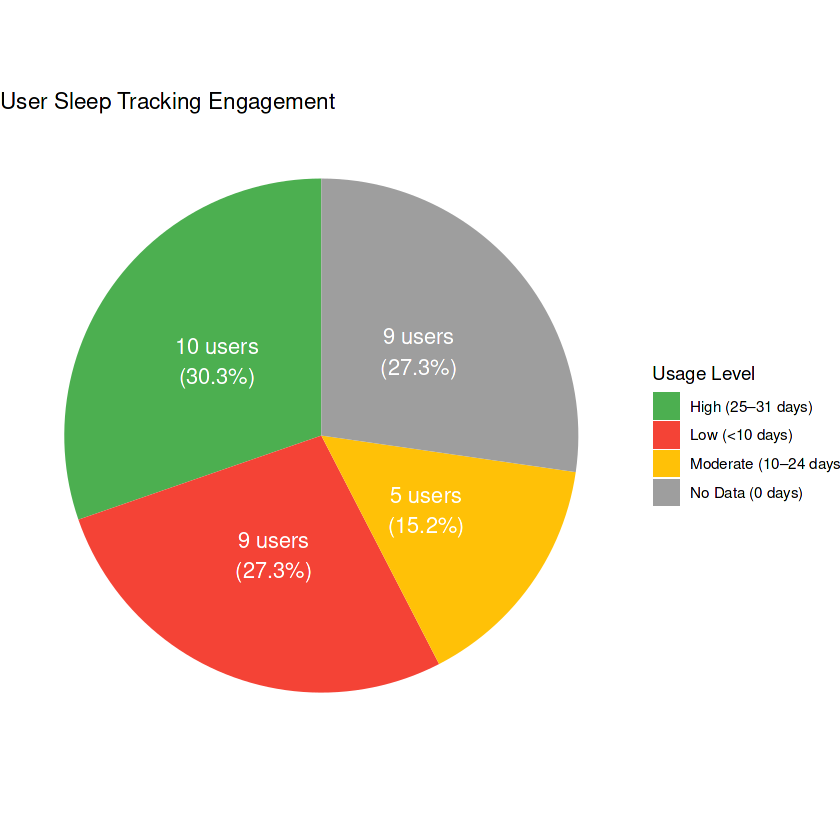

In [245]:
# Counting number of days each user logged sleep
sleep_usage <- daily_merged_df_cleaned %>%
  group_by(Id) %>%
  summarise(days_logged = sum(!is.na(TotalSleepRecords))) %>%
  ungroup()

# Categorizing users by engagement level, separate NA/0
sleep_usage <- sleep_usage %>%
  mutate(usage_category = case_when(
    days_logged == 0 ~ "No Data (0 days)",
    days_logged >= 25 ~ "High (25–31 days)",
    days_logged >= 10 ~ "Moderate (10–24 days)",
    days_logged < 10 ~ "Low (<10 days)"
  ))

# Counting users in each category and calculating %
usage_summary <- sleep_usage %>%
  count(usage_category) %>%
  mutate(percentage = n / sum(n) * 100)


# Pie chart with counts and percentages
ggplot(usage_summary, aes(x = "", y = n, fill = usage_category)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  labs(title = "User Sleep Tracking Engagement", fill = "Usage Level") +
  theme_void() +
  geom_text(aes(label = paste0(n, " users\n(", round(percentage,1), "%)")), 
            position = position_stack(vjust = 0.5), color = "white", size = 4.5) +
  scale_fill_manual(values = c(
    "High (25–31 days)" = "#4CAF50", 
    "Moderate (10–24 days)" = "#FFC107", 
    "Low (<10 days)" = "#F44336",
    "No Data (0 days)" = "#9E9E9E"
  ))


### **Observation**
- The pie chart shows thre user traccking engagement. Here is possible to see that 33.3% of users tracked sleep consistently (≥25 days); 27.3% tracked sleep rarely (<10 days); 27.3% tracked sleep moderately (10–24 days); and 27.3% had no data registered.
  
**Insight**:
- Around a third of users are highly engaged, but a similar number only track their sleep rarely or not at all. This might be because some users forget to wear their sleep tracker at night, turn it off, or leave it on the charger.
- Encouraging regular use through reminders, incentives, showing the benefits of or designing a more ergonimic tracker device could help increase consistent usage.

### 5.2.2. Daily Sleep Data Missingness Patterns

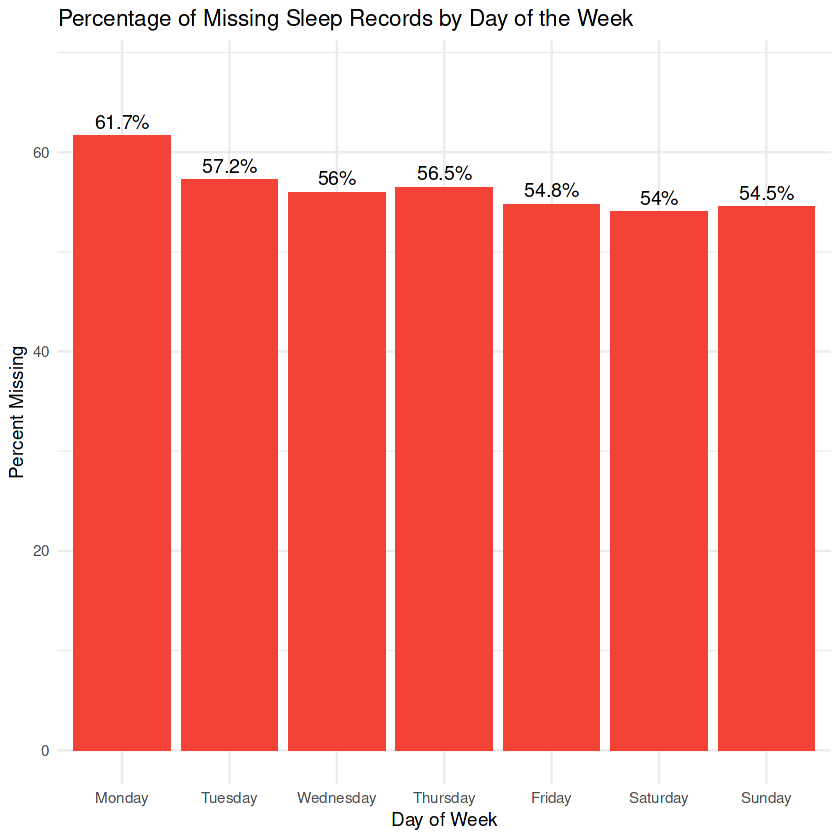

In [246]:
# Adding day of week to daily data
daily_merged_df_cleaned <- daily_merged_df_cleaned %>%
  mutate(day_of_week = wday(DateOnly, label = TRUE, abbr = FALSE)) %>%
  mutate(day_of_week = factor(day_of_week, 
                             levels = c("Monday", "Tuesday", "Wednesday", "Thursday", 
                                        "Friday", "Saturday", "Sunday")))  # order days Monday-Sunday


# Calculation of missing sleep records by day of the week
sleep_missing_by_day <- daily_merged_df_cleaned %>%
  group_by(day_of_week) %>%
  summarise(
    total_days = n(),                                  # total records per day
    missing_sleep = sum(is.na(TotalSleepRecords)),     # counting missing sleep records
    missing_pct = missing_sleep / total_days * 100     # percentage missing
  )


# Missing sleep percentages by day of week
ggplot(sleep_missing_by_day, aes(x = day_of_week, y = missing_pct)) +
  geom_col(fill = "#F44336") +
  geom_text(aes(label = paste0(round(missing_pct, 1), "%")), 
            vjust = -0.5, size = 4, color = "black") +
  labs(
    title = "Percentage of Missing Sleep Records by Day of the Week",
    x = "Day of Week",
    y = "Percent Missing"
  ) +
  theme_minimal() +
  ylim(0, max(sleep_missing_by_day$missing_pct) * 1.1)


**Observation**
The bar chart shows the percentage of missing sleep record per day of the week. It is possible to see that Monday (61,7%) is the day with most missing sleep data while weekend days have the least (Saturday: 54%, Sunday: 54,5%).

**Insight**
- Forget wearing the sleep tracker at sleep may explain these result, these could associate to removing device for chaging it at night,or because is uncofortable for sleep, etc. 
- During the weekends the usage increse while reaching monday decrease.
- Bellabeat may encourage sleep tracking usage by sending reminders during the day, by ergonomic confortable designs and by improve charging speed time to decrease users fall asleep before the devide is charged. 

### 5.2.3. Median Time awake in bed

In [247]:
# Calculating median awake time in bed
daily_merged_df_cleaned <- daily_merged_df_cleaned %>%
  mutate(time_awake_in_bed = TotalTimeInBed - TotalMinutesAsleep)

# Median
median_awake_in_bed <- daily_merged_df_cleaned %>%
  filter(!is.na(time_awake_in_bed)) %>%
  summarise(median_awake_in_bed = median(time_awake_in_bed))


median_awake_in_bed



median_awake_in_bed
<dbl>
25.5


**Observation**
- Participants spend a median of 25.5 minutes awake in bed.

**Insight**
- 25.5 minutes awake in bed which could indicate difficulties with falling asleep, restlessness or a fragmented sleep.
- Bellabeat could use this time to send reminders to use sleep trackers, send daily achievements summary, mindfulness and breathing exercises, etc, for better sleep.

### 5.2.4. Sleep efficiency

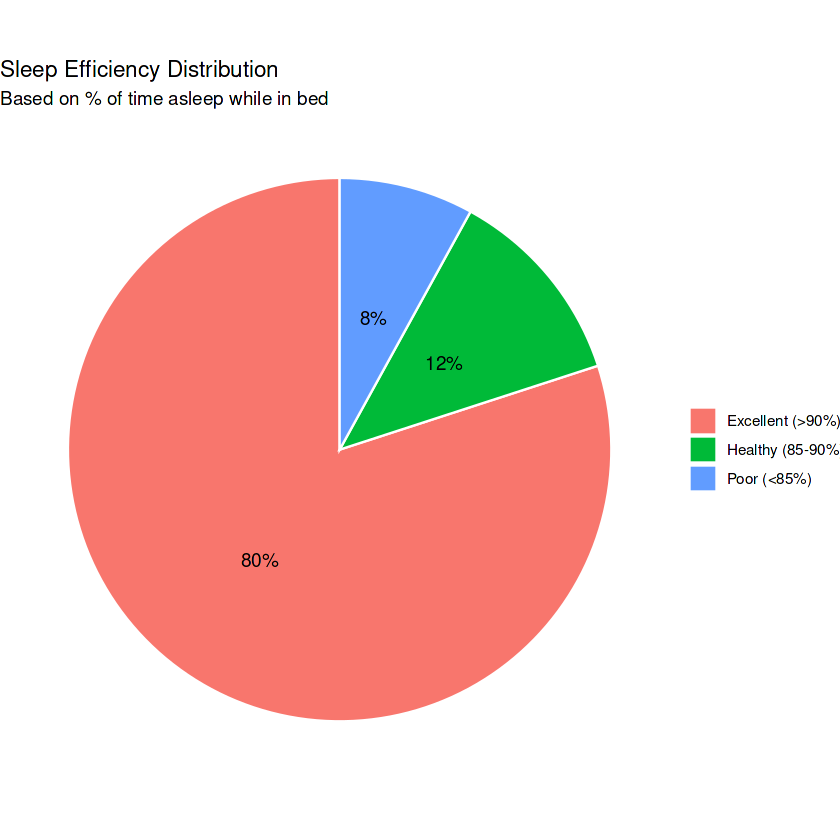

In [248]:
# Calculation sleep efficiency and adding a new column
daily_merged_df_cleaned <- daily_merged_df_cleaned %>%
  mutate(
    sleep_efficiency = (TotalMinutesAsleep / TotalTimeInBed) * 100
  )



# Sleep efficiency with labels
sleep_efficiency_pie <- daily_merged_df_cleaned %>%
  filter(!is.na(sleep_efficiency)) %>%
  mutate(
    SleepEfficiency = case_when(
      sleep_efficiency < 85 ~ "Poor (<85%)",
      sleep_efficiency >= 85 & sleep_efficiency <= 90 ~ "Healthy (85-90%)",
      sleep_efficiency > 90 ~ "Excellent (>90%)"
    )
  ) %>%
  count(SleepEfficiency) %>%
  mutate(Percentage = round(n / sum(n) * 100, 1))



# Plot pie chart
ggplot(sleep_efficiency_pie, aes(x = "", y = Percentage, fill = SleepEfficiency)) +
  geom_col(width = 1, color = "white") +
  coord_polar(theta = "y") +
  geom_text(aes(label = paste0(Percentage, "%")), 
            position = position_stack(vjust = 0.5)) +
  labs(
    title = "Sleep Efficiency Distribution",
    subtitle = "Based on % of time asleep while in bed"
  ) +
  theme_void() +
  theme(legend.title = element_blank())


**Observation**
- The pie chart shows that 80% of users have excelent sleep efficiency, followed by 12% with healthy sleep efficiency, and 8% with poor sleep efficiency.

**Insight**

- While most of the users have excellent sleep efficiency, a small portion struggles to maintain consistent, restful sleep. These users my be restless at night or having multiple awakenings breaking during the sleep.
- Bellabeat could introduce personalized support features for those users with lower sleep efficiency such as reminders, tips for sleep in a good environtment, relaxation routines by a coach, etc.

## 5.3. Physical Activity Patterns

### 5.3.1. Median Total Steps by Day of the Week 

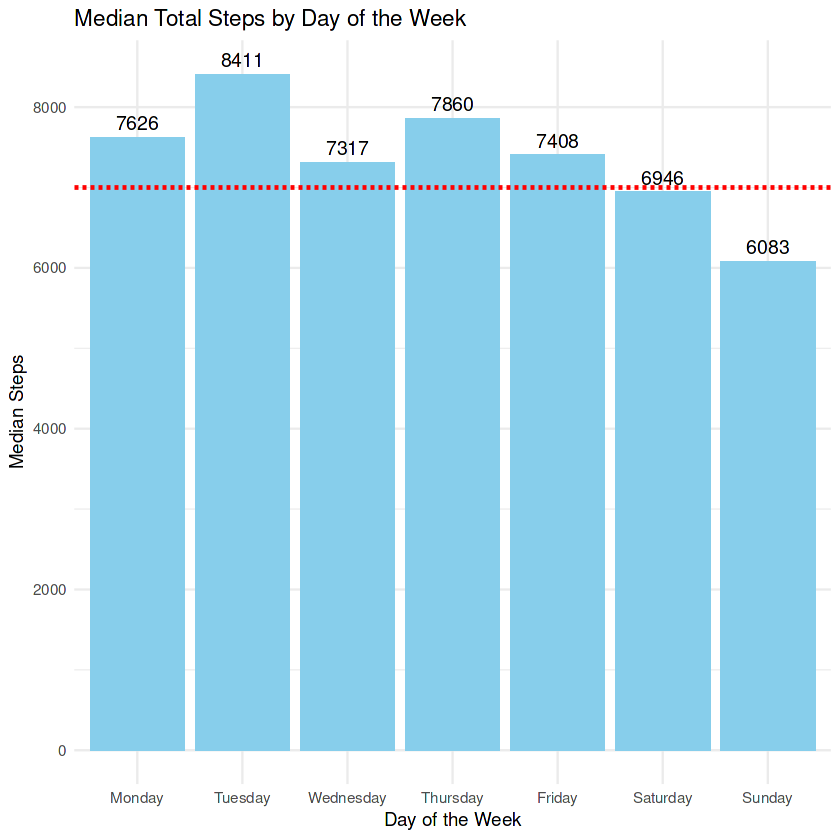

In [249]:
# Calculating median steps by weekday
daily_steps_by_day <- daily_merged_df_cleaned %>%
  mutate(Weekday = wday(DateOnly, label = TRUE, abbr = FALSE)) %>%
  mutate(Weekday = fct_relevel(Weekday, 
                               "Monday", "Tuesday", "Wednesday", 
                               "Thursday", "Friday", "Saturday", "Sunday")) %>%
  group_by(Weekday) %>%
  summarise(median_steps = median(TotalSteps, na.rm = TRUE)) %>%
  ungroup()

# Plot median steps
ggplot(daily_steps_by_day, aes(x = Weekday, y = median_steps)) +
  geom_col(fill = "skyblue") +
  geom_text(aes(label = round(median_steps)), 
            vjust = -0.5, size = 4, color = "black") +
  geom_hline(yintercept = 7000, linetype = "dashed", color = "red", size = 1) +
  labs(
    title = "Median Total Steps by Day of the Week",
    y = "Median Steps",
    x = "Day of the Week"
  ) +
  theme_minimal()


**Observation**
- The chart shows the median steps/day by the users. On weekdays users seem to have the highest median steps/day, with Tuesday and Thursday having the highest values (8411 and 7860, respectively). In contrast, Saturaday (6946) and Sunday (6083) are the days with the least median steps/day. Overall, all weekdays met the WHO recommendations while weekends did not. 
  
- **Insight**
Users are more active on weekdays and meet the WHO steps/day goal, while weekend activity drops.

### 5.3.2. Median Steps/hour by weekdays and weekend

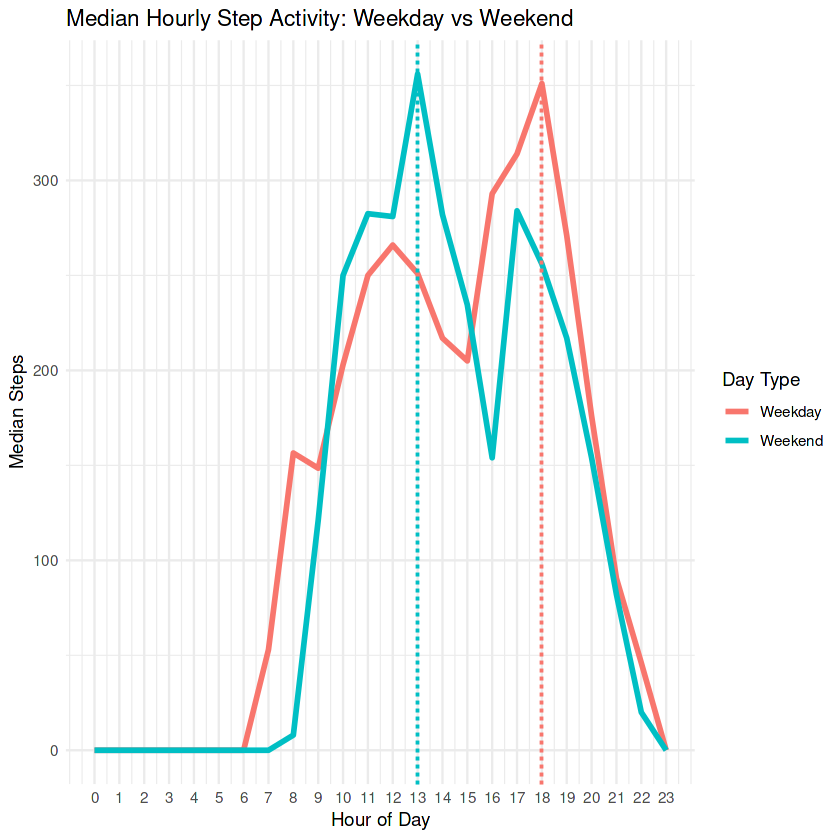

In [250]:
# Preparing the data to separate weekdays and weekend
steps_hourly_df <- steps_hourly_df %>%
  mutate(
    DayOfWeek = wday(DateTime, label = TRUE, abbr = TRUE, week_start = 1),
    DayOfWeek = factor(DayOfWeek, levels = c("Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun")),
    Hour = hour(DateTime),
    DayType = ifelse(DayOfWeek %in% c("Sat", "Sun"), "Weekend", "Weekday")
  )



# Summarize median steps per hour by DayType
activity_by_hour <- steps_hourly_df %>%
  group_by(DayType, Hour) %>%
  summarise(MedianSteps = median(StepTotal, na.rm = TRUE), .groups = "drop")



# Plot
ggplot(activity_by_hour, aes(x = Hour, y = MedianSteps, color = DayType)) +
  geom_line(size = 1.2) +
  geom_vline(data = activity_by_hour %>%
               group_by(DayType) %>%
               slice_max(MedianSteps),
             aes(xintercept = Hour, color = DayType),
             linetype = "dashed", size = 0.8, show.legend = FALSE) +
  labs(title = "Median Hourly Step Activity: Weekday vs Weekend",
       x = "Hour of Day",
       y = "Median Steps",
       color = "Day Type") +
  scale_x_continuous(breaks = 0:23) +
  theme_minimal()

**Observation**
- The line graph shows the median steps per hour divided into weekdays (Monday to Friday) and weekends (Saturday–Sunday).
- Weekday activity starts around 6 a.m., with the first small peak at 8 a.m. (approx. 150 steps/hour), followed by a second peak around 12 p.m. (approx. 260 steps/hour), and a final and highest peak at 6 p.m. (approx. 350 steps/hour).
- Weekend activity tends to start later than on weekdays, with the highest peak at 1 p.m. (approx. 360 steps/hour) and another peak at 5 p.m. (approx. 280 steps/hour).
Overall, on weekdays the main peak is in the evening, while on weekends it is in the early afternoon.

**Insight**
- The weekday pattern matches well with free time before work, during breaks, and after work, with afternoons and evenings being more active. This may be because users tend to go to the gym after work. On weekends, users tend to start activity later in the day, with the highest peak in the late morning and another smaller peak in the early afternoon, after which activity slows down, suggesting more relaxing activities.


### 5.3.3. Weekly active minutes WHO Physical activity recommendation.

In [251]:
# Add week and weekday columns to daily_merged_df_cleaned dataset
daily_with_week <- daily_merged_df_cleaned %>%
  mutate(
    week = floor_date(DateOnly, unit = "week", week_start = 1),  # Week starts on Monday
    weekday = wday(DateOnly, week_start = 1)  # 1 = Monday, 7 = Sunday
  )


# Filter only full weeks (Monday to Sunday) per participant
complete_weeks <- daily_with_week %>%
  group_by(Id, week) %>%
  filter(n_distinct(weekday) == 7) %>%  # This is for only keep complete weeks
  ungroup()


# Calculating weekly active minutes (only from complete weeks)
weekly_active_minutes <- complete_weeks %>%
  group_by(Id, week) %>%
  summarise(
    weekly_very = sum(VeryActiveMinutes, na.rm = TRUE),
    weekly_fairly = sum(FairlyActiveMinutes, na.rm = TRUE),
    weekly_lightly = sum(LightlyActiveMinutes, na.rm = TRUE),
    .groups = "drop"
  )


# Converting data to long format for plotting 
weekly_long <- weekly_active_minutes %>%
  pivot_longer(
    cols = starts_with("weekly_"),
    names_to = "activity_type",
    values_to = "minutes"
  )

# Calculating WHO equivalent score and compliance
weekly_who_score <- weekly_active_minutes %>%
  mutate(
    # Light activity NOT counted in WHO score
    combined_score = weekly_fairly + (weekly_very * 2),
    met_who_guidelines = combined_score >= 150
  )
weekly_who_score

Id,week,weekly_very,weekly_fairly,weekly_lightly,combined_score,met_who_guidelines
<chr>,<date>,<int>,<int>,<int>,<dbl>,<lgl>
1503960366,2016-04-18,285,120,1543,690,TRUE
1503960366,2016-04-25,331,157,1633,819,TRUE
1503960366,2016-05-02,277,145,1651,699,TRUE
1624580081,2016-04-18,33,25,1291,91,FALSE
1624580081,2016-04-25,214,127,1156,555,TRUE
1624580081,2016-05-02,7,6,933,20,FALSE
1644430081,2016-04-18,20,106,897,146,FALSE
1644430081,2016-04-25,34,190,1330,258,TRUE
1644430081,2016-05-02,69,136,1409,274,TRUE


### 5.3.4. Bar plot showing if participants met WHO guidelines per week

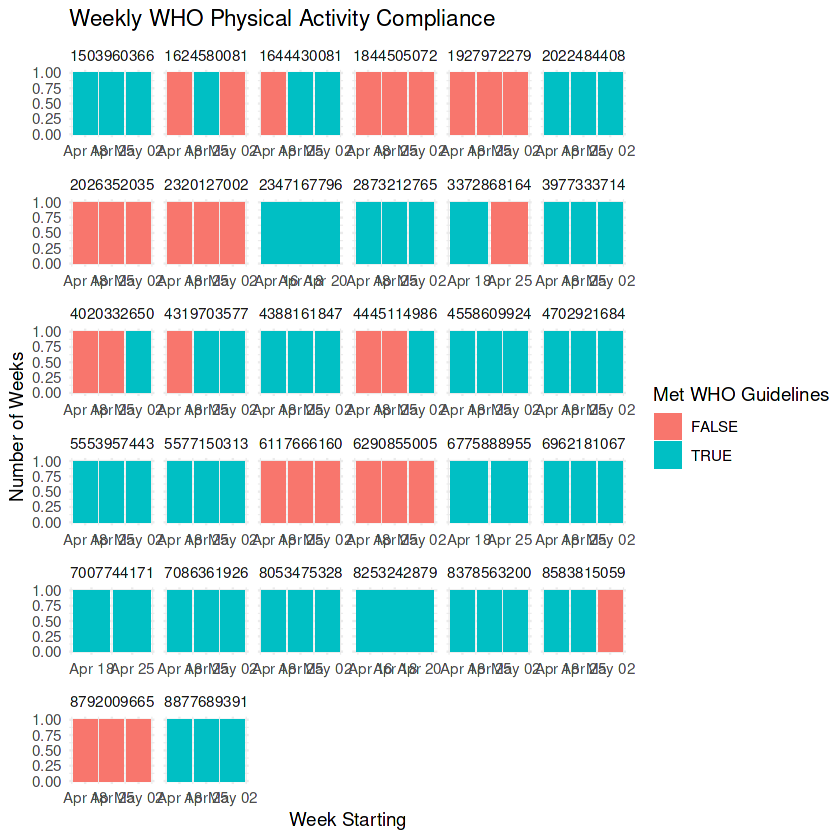

In [252]:

ggplot(weekly_who_score, aes(x = week, fill = met_who_guidelines)) +
  geom_bar(position = "dodge") +
  facet_wrap(~Id, scales = "free_x") +
  labs(
    title = "Weekly WHO Physical Activity Compliance",
    x = "Week Starting",
    y = "Number of Weeks",
    fill = "Met WHO Guidelines"
  ) +
  theme_minimal()

**Observation**
The charts show weekly compliance with WHO physical activity guidelines for each user. Some participants consistently meet the WHO requimentment while others seem to have irregular or low compliance. 

**Insight**
- Variability in compliance may suggests barriers like motivation or time constraints.
- This suggests that users may need new challenges to stay engaged and be more active.

### 5.3.5. Percentage of Weeks Each Participant Met WHO Activity Guidelines

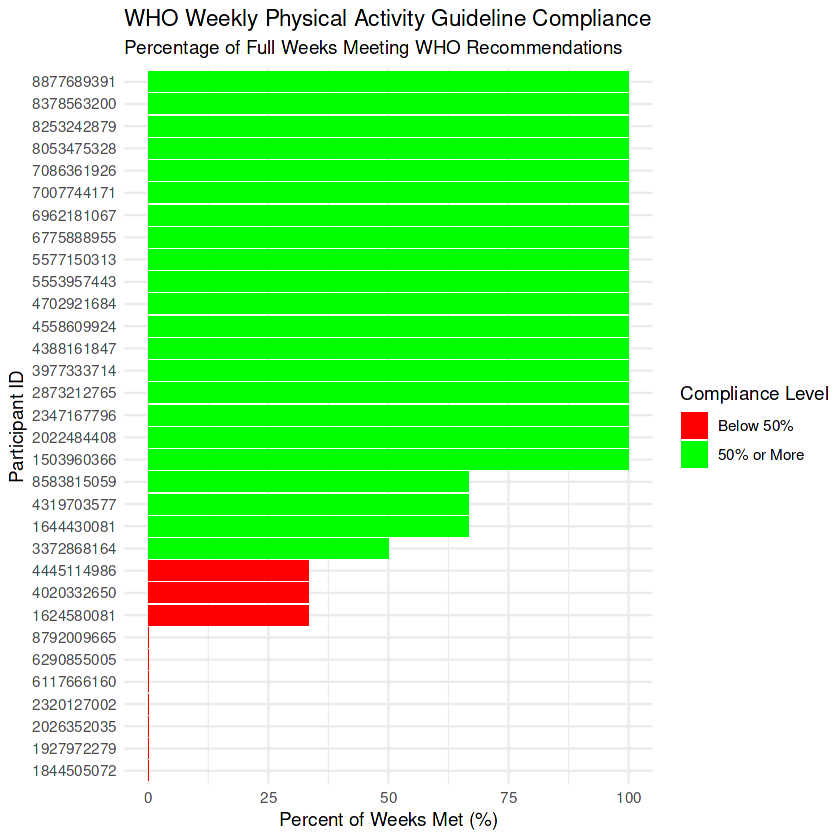

In [253]:
# % of weeks each participant met WHO guidelines
summary_compliance <- weekly_who_score %>%
  group_by(Id) %>%
  summarise(
    total_weeks = n(),
    weeks_met = sum(met_who_guidelines),
    percent_weeks_met = (weeks_met / total_weeks) * 100
  )

# Plot compliance with colored bars based on 50% cutoff
ggplot(summary_compliance, aes(x = reorder(Id, percent_weeks_met), 
                               y = percent_weeks_met, 
                               fill = percent_weeks_met >= 50)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual(values = c("red", "green"), 
                    labels = c("Below 50%", "50% or More"),
                    name = "Compliance Level") +
  labs(
    title = "WHO Weekly Physical Activity Guideline Compliance",
    subtitle = "Percentage of Full Weeks Meeting WHO Recommendations",
    x = "Participant ID",
    y = "Percent of Weeks Met (%)"
  ) +
  theme_minimal()


**Observation**
- The chart shows the participants by ID and the number of full weeks in which they met the WHO physical activity (PA) requirements. It is evident that 22 out of 33 participants met the WHO requirements in 50% or more of the weeks, while 10 participants did not.
According to the chart, 18 participants fulfilled the WHO PA requirements in all their full weeks and followed by 4 participants who met the requirements in more than 50% of the weeks. In contrast, 3 participants met the requirements in approximately 30% of the weeks, and 7 participants did not meet the weekly PA requirements at all.

**Insight**
- This suggests most participants maintain regular activity, but a reduced number struggle with adherence.

## 5.4. Relationships between variables activity, sleep, calories.

### 5.4.1. Relationship Total Steps and Sleep duration

`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(daily_merged_df_cleaned$TotalMinutesAsleep, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  daily_merged_df_cleaned$TotalMinutesAsleep and daily_merged_df_cleaned$TotalSteps
S = 14066506, p-value = 4.382e-06
alternative hypothesis: true rho is not equal to 0
sample estimates:
       rho 
-0.2245838 


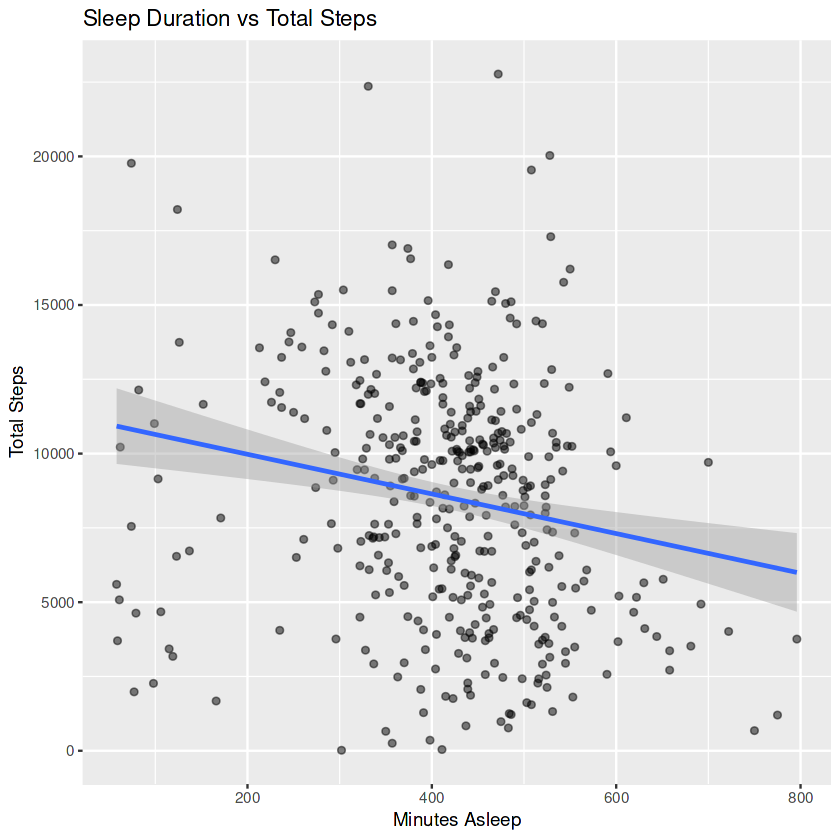

In [254]:
# Scatter plot: total steps vs minutes asleep
daily_merged_df_cleaned %>%
  filter(!is.na(TotalMinutesAsleep), !is.na(TotalSteps)) %>%
  ggplot(aes(x = TotalMinutesAsleep, y = TotalSteps)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "lm") +
  labs(title = "Sleep Duration vs Total Steps", x = "Minutes Asleep", y = "Total Steps")


# Correlation test Steps and Sleep duration.
cor.test(daily_merged_df_cleaned$TotalMinutesAsleep, daily_merged_df_cleaned$TotalSteps, use = "complete.obs", method = "spearman")

**Observation**
- The scatter plot total step vs sleep duration and the correlation tests suggest there is a weak statistically significant negative correlation between total steps and minutes asleep. (Spearman rho:-0.22; p-values < 0.05 ). 

**Insight**
- Although the correlation is significant, -0.22 is weak, so total steps explain very little the variation in sleep duration. Other factors such as stress or lifestyle may have a stronger influence.

### 5.4.2. Relationship Total Steps and Calories Burned


`geom_smooth()` using formula = 'y ~ x'
Warning message in cor.test.default(daily_merged_df_cleaned$TotalSteps, daily_merged_df_cleaned$Calories, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  daily_merged_df_cleaned$TotalSteps and daily_merged_df_cleaned$Calories
S = 61010776, p-value < 2.2e-16
alternative hypothesis: true rho is not equal to 0
sample estimates:
      rho 
0.5592679 


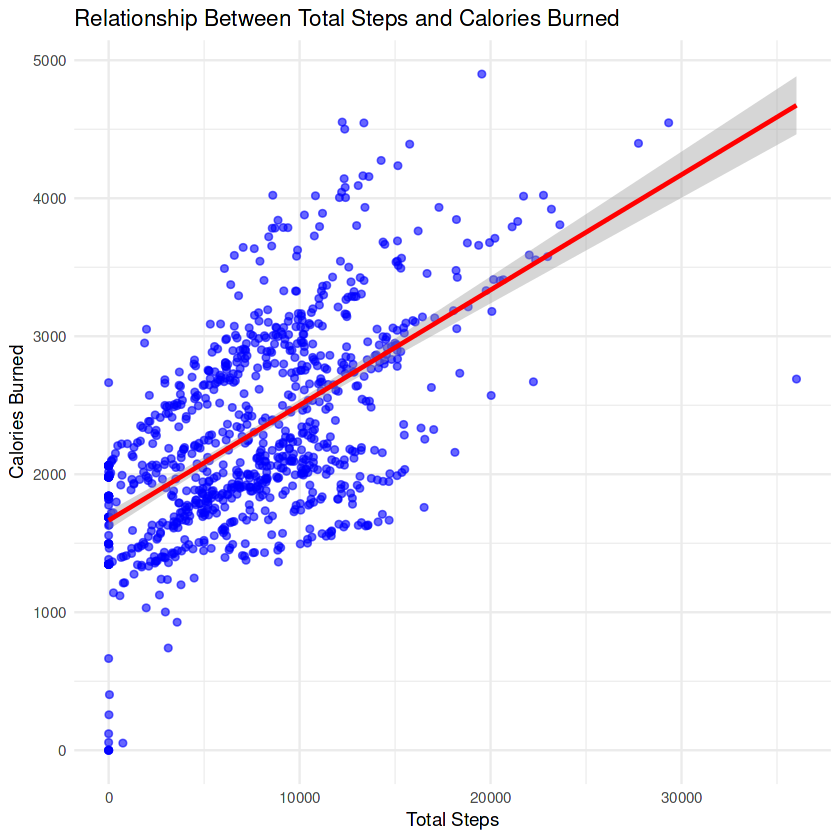

In [255]:
## Plot Total steps vs Calories Burned
ggplot(daily_merged_df_cleaned, aes(x = TotalSteps, y = Calories)) +
  geom_point(alpha = 0.6, color = "blue") +
  geom_smooth(method = "lm", se = TRUE, color = "red") +
  labs(
    title = "Relationship Between Total Steps and Calories Burned",
    x = "Total Steps",
    y = "Calories Burned"
  ) +
  theme_minimal() 

# Correlation Total Steps and Calories Burned
cor.test(daily_merged_df_cleaned$TotalSteps, daily_merged_df_cleaned$Calories, use = "complete.obs", method = "spearman")

**Observation**
- The scatter plot of total steps vs. calories burned and the correlation test shows a moderate, statistically significant positive relationship between the 2 variables (Spearman’s ρ: 0.56; p-values < 0.05). 

**Insight**
- This suggests that more steps are significantly associated with more calories burned during activity.

### 5.4.3. Relationship Sleep Duration and Calories Burned

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 530 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 530 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message in cor.test.default(daily_merged_df_cleaned$Calories, daily_merged_df_cleaned$TotalMinutesAsleep, :
“Cannot compute exact p-value with ties”



	Spearman's rank correlation rho

data:  daily_merged_df_cleaned$Calories and daily_merged_df_cleaned$TotalMinutesAsleep
S = 11929269, p-value = 0.4366
alternative hypothesis: true rho is not equal to 0
sample estimates:
        rho 
-0.03852297 


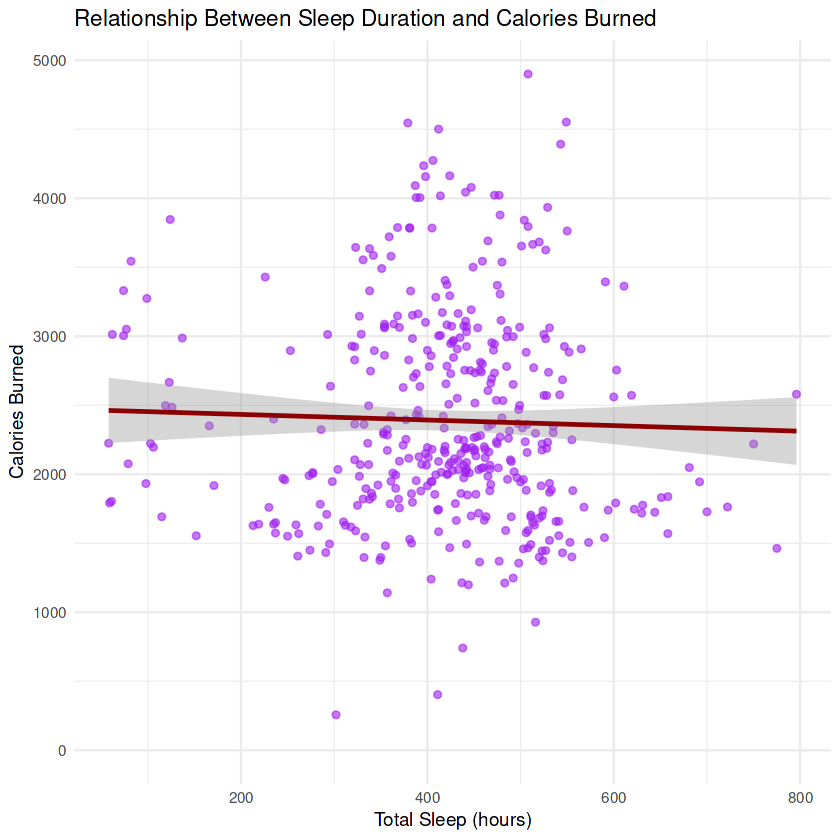

In [256]:
# Scatter plot Sleep Duration and Calories Burned
ggplot(daily_merged_df_cleaned, aes(x = TotalMinutesAsleep, y = Calories)) +
  geom_point(alpha = 0.6, color = "purple") +
  geom_smooth(method = "lm", se = TRUE, color = "darkred") +
  labs(
    title = "Relationship Between Sleep Duration and Calories Burned",
    x = "Total Sleep (hours)",
    y = "Calories Burned"
  ) +
  theme_minimal()

# Correlation Sleep Duration and Calories Burned
cor.test(daily_merged_df_cleaned$Calories, daily_merged_df_cleaned$TotalMinutesAsleep, use = "complete.obs", method = "spearman")

**Observation**

- The scatter plot of sleep duration vs. calories burned and the correlation test indicate a very weak, non-significant negative relationship between sleep duration and calories burned (Spearman’s ρ = -0.04, p > 0.05).
  
**Insight**
- This suggests that longer sleep does not necessarily correspond to higher calories burned.

# **6. Summary and conclusions** (Share) 


**Sleep Tracking**

1. Sleep was tracked consistently (≥25 days) by most users (33.3%), moderately (10–24 days) by 15.3%, and rarely (<10 days) or not at all by 27.3%.
This might be because some users forget to wear their sleep tracker at night, turn it off, leave it on the charger, or intentionally remove it due to discomfort.

3. Sleep data tracking was missed the most on Mondays (61.7%), while it was missed least on weekends (54–54.5%). This suggests that users tend to track their sleep more on weekends than on weekdays.

4. Users spent a median of 25.5 minutes awake in bed. According to sleepfoundation.org it should take less than 20 minutes to fall asleep. Therefore, this result is slightly higher than the recommended duration which suggests that some users may have difficulties to fall asleep.

5. Most of the users (80% of them) had an healthy or excellent sleep efficiency and only 8% have poor sleep (<85%). While the sleep efficiency is high in the most users, a minority may struggle with fragmented sleep.




**Physical Activity**

1. Users are most active on weekdays, with peak activity in the evening, while on weekend activity starts later and peaks highest in the early afternoon. This suggests that lifestyle and work schedules strongly influence daily activity patterns of the users.
   
2. Weekends do not meet the WHO daily steps recommendations. This highlights the need for personalize strategies to meet the daily step goal on weekends.

3. The majority of users meet the weekly amount of physical activity minutes recommended by the WHO; however, some users show inconsistent adherence. This suggest that may be differences in motivation or time availability among users.

4. Steps moderately predict calories burned (ρ = 0.56) but have little impact on sleep duration (ρ = -0.22). Sleep duration and calories burned are unrelated (ρ = -0.04). This suggests that while step count influences energy expenditure, other factors like stress, lifestyle, or routines may affect sleep duration.


# **7. Recommendations** (Act)

After analyzing the information from the Fitbit datasets, multiple insights were identified to improve Bellabeat products, to provide the best services to their clients, and to become the reference to follow.
The recommendations derived from this project includes: 

*Increase sleep tracker engagement*:
- Using reminders to remember users to wear their sleep trackers at night.
- Use reminders to wear the sleep tracking at night, especially during weekdays.
- Bellabeat may introduce faster chargers or reminders for charging on time.
- Design ergonomic and confortable trackers devices.


*Target Sleep Difficulties*:
- Use personalized sleep tips for users with more than 20 minutes in bed at night without sleeping.
- Integrate on the Bellabeat app guided sleep meditation, minfulness  or breathing exercises.
- Introduce notifications to remind consistent bedtime or reducing screen time at night.


*Monitoring Fragmented Sleep*:
- Bellabeat may create for users with poor sleep efficiency alerts or insights about the causes of that, such as stress during the day, high caffeine consumption at night, or  schedules that are irregular.
- Create awareness among users by offering sleep reports by week with recommendation to improve sleep.


*Increase Weekend Activity among users*:
- Encourage activity and increase daily steps on weekend by creating weekend-specific challenges.
- Interconect Bellabeat between users and organize duo or group challeges.
- Suggest through Bellabeat app diverse family-friendly panoramas or outdoor activities taking place in the users city.


*Increase Users Motivation*:
- Introduce games or reward based systems for users with inconsistent activity (steps) or sleep.
- Personalized reminders and coaching advise according user activity time.
- Use motivational quotes when activity or sleep is deficient.
- Introduce social features such as forums to encourage peer support and motivation. For example a social forum where users can share their achievement with other members and make challenges together.

    
*General recommendations*:
- Since steps alone do not impact sleep duration, integrate stress, diet, and lifestyle follow up.
- Provide calorie insights beyond step count (for example: calories from non-walking activities).
- Personalized notifications during low activity times, for example on Mondays or weekends.
- Promote daily reflection on sleep and activity goals.
- Identify groups with poor sleep efficiency or inconsistent activity and target programs for them.
  